TTC Subway Delay Prediction — Model Training - Phase 1

Author: ... Date: February 2026
Input: cleaned_ttc_delay_data.csv (from preprocessing notebook)
Objective: Train a binary classification model to predict if a subway delay will occur (delay vs. no delay)

1. Setup & Data Loading
Import required libraries and load the preprocessed dataset.

Libraries needed:

pandas, numpy — data manipulation
scikit-learn — model training, evaluation, preprocessing
matplotlib, seaborn — visualization
xgboost or lightgbm — gradient boosting models (optional

In [ ]:
# --- Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


# --- Load Data ---
df = pd.read_csv('/content/sample_data/cleaned_ttc_delay_data.csv', parse_dates=['Date'])

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nTarget summary (min_delay_capped):\n{df['min_delay_capped'].describe()}")
print(f"\nZero-delay ratio: {(df['min_delay_capped'] == 0).mean():.1%}")
df.head()

Shape: (52059, 14)

Column types:
Date                        datetime64[ns]
Line                                object
Station                             object
Code                                object
hour                                 int64
day_of_week                          int64
is_weekend                           int64
month                                int64
week                                 int64
year                                 int64
min_delay_capped                     int64
route_avg_delay                    float64
route_hour_avg_delay               float64
route_day_hour_avg_delay           float64
dtype: object

Target summary (min_delay_capped):
count    52059.000000
mean         2.600165
std          5.740640
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max         60.000000
Name: min_delay_capped, dtype: float64

Zero-delay ratio: 64.5%


,Date,Line,Station,Code,hour,day_of_week,is_weekend,month,week,year,min_delay_capped,route_avg_delay,route_hour_avg_delay,route_day_hour_avg_delay
0,2024-01-01,Line 1,SHEPPARD STATION,MUI,2,0,0,1,1,2024,0,2.860133,0.623867,0.630631
1,2024-01-01,Line 1,DUNDAS STATION,MUIS,2,0,0,1,1,2024,0,2.860133,0.623867,0.630631
2,2024-01-01,Line 1,DUNDAS STATION,MUPAA,2,0,0,1,1,2024,4,2.860133,0.623867,0.630631
3,2024-01-01,Line 2,KENNEDY BD STATION,PUTDN,2,0,0,1,1,2024,10,2.352354,0.473251,1.017857
4,2024-01-01,Line 1,BLOOR STATION,MUPAA,2,0,0,1,1,2024,4,2.860133,0.623867,0.630631


**2. Feature Preparation**

Prepare the feature matrix (X) and target vector (y) for model training.

2.1  Define Features and Target

In [ ]:
target = 'min_delay_capped'
y = df[target]

X = df.drop(columns=['Date', target])

cat_cols = ['Line', 'Station', 'Code']
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Target: {target}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")
for col in cat_cols:
    print(f"  {col}: {X[col].nunique()} unique values")
print(f"\nNumeric features ({len(num_cols)}): {num_cols}")
print(f"\nX shape: {X.shape}")
X.head()

Target: min_delay_capped

Categorical features (3): ['Line', 'Station', 'Code']
  Line: 4 unique values
  Station: 731 unique values
  Code: 130 unique values

Numeric features (9): ['hour', 'day_of_week', 'is_weekend', 'month', 'week', 'year', 'route_avg_delay', 'route_hour_avg_delay', 'route_day_hour_avg_delay']

X shape: (52059, 12)


,Line,Station,Code,hour,day_of_week,is_weekend,month,week,year,route_avg_delay,route_hour_avg_delay,route_day_hour_avg_delay
0,Line 1,SHEPPARD STATION,MUI,2,0,0,1,1,2024,2.860133,0.623867,0.630631
1,Line 1,DUNDAS STATION,MUIS,2,0,0,1,1,2024,2.860133,0.623867,0.630631
2,Line 1,DUNDAS STATION,MUPAA,2,0,0,1,1,2024,2.860133,0.623867,0.630631
3,Line 2,KENNEDY BD STATION,PUTDN,2,0,0,1,1,2024,2.352354,0.473251,1.017857
4,Line 1,BLOOR STATION,MUPAA,2,0,0,1,1,2024,2.860133,0.623867,0.630631


**2.2 Encode Categorical** **Features**

In [ ]:
# 2.2 Encode Categorical Features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = ohe.fit_transform(X[cat_cols])

X_cat_encoded_df = pd.DataFrame(X_cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=X.index)

X = pd.concat([X[num_cols], X_cat_encoded_df], axis=1)

print(f"X shape after encoding: {X.shape}")
display(X.head())

X shape after encoding: (52059, 874)


,hour,day_of_week,is_weekend,month,week,year,route_avg_delay,route_hour_avg_delay,route_day_hour_avg_delay,Line_Line 1,...,Code_TUO,Code_TUOPO,Code_TUOS,Code_TUS,Code_TUSC,Code_TUSET,Code_TUST,Code_TUSUP,Code_TUUR,Code_XXXXX
0,2,0,0,1,1,2024,2.860133,0.623867,0.630631,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0,0,1,1,2024,2.860133,0.623867,0.630631,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0,0,1,1,2024,2.860133,0.623867,0.630631,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,0,0,1,1,2024,2.352354,0.473251,1.017857,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,0,0,1,1,2024,2.860133,0.623867,0.630631,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.3 Save Encoded Data and Encoder

It's good practice to save the preprocessed data, the fitted encoder, and the feature names. This ensures reproducibility and allows for consistent preprocessing of new data for prediction.

In [ ]:
import joblib

# Save the OneHotEncoder object
joblib.dump(ohe, '/content/sample_data/one_hot_encoder.pkl')
print("OneHotEncoder saved as one_hot_encoder.pkl")

# Save the preprocessed features (X) and target (y)
X.to_csv('/content/sample_data/encoded_features_X.csv', index=False)
y.to_csv('/content/sample_data/target_y.csv', index=False)
print("Encoded features X and target y saved to CSV")

# Save the list of feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, '/content/sample_data/feature_names.pkl')
print("Feature names saved as feature_names.pkl")

OneHotEncoder saved as one_hot_encoder.pkl
Encoded features X and target y saved to CSV
Feature names saved as feature_names.pkl


##3. Implement Train/Test Split

Split the preprocessed data (X and y) into training and testing sets using a time-based split, ensuring the test set consists of the latest data. Then, save these split datasets to CSV files.

**Reasoning**:
The subtask requires splitting the data into training and testing sets using a time-based split, with the last 20% of the data reserved for testing. This involves calculating the split index, then slicing the X and y DataFrames/Series accordingly, and finally saving the resulting subsets to CSV files.



In [ ]:
# 3. Train/Test Split

# 1. Determine the split point (last 20% for testing)
split_index = int(len(X) * 0.8)
print(f"Split index: {split_index} (80% of {len(X)} rows)")

# 2. Divide X into X_train and X_test
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# 3. Divide y into y_train and y_test
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# 4. Save the split datasets to CSV files
X_train.to_csv('/content/sample_data/X_train.csv', index=False)
X_test.to_csv('/content/sample_data/X_test.csv', index=False)
y_train.to_csv('/content/sample_data/y_train.csv', index=False)
y_test.to_csv('/content/sample_data/y_test.csv', index=False)

print("\nTrain and test datasets saved to CSV files.")

Split index: 41647 (80% of 52059 rows)

X_train shape: (41647, 874)
X_test shape: (10412, 874)
y_train shape: (41647,)
y_test shape: (10412,)

Train and test datasets saved to CSV files.


## Summary:

### Data Analysis Key Findings
*   The preprocessed features and target were split into training and testing sets using a time-based split, with the last 20% of the data reserved for testing. For a dataset of 52059 rows, the split index was determined to be 41647.
*   The resulting training features (`X_train`) have a shape of (41647, 874), while the testing features (`X_test`) have a shape of (10412, 874).
*   The corresponding training target (`y_train`) has a shape of (41647,), and the testing target (`y_test`) has a shape of (10412,).
*   All four datasets ($\text{X\_train}$, $\text{X\_test}$, $\text{y\_train}$, $\text{y\_test}$) were successfully saved as individual CSV files (e.g., $\text{X\_train.csv}$) to the `/content/sample_data/` directory.

### Next Steps
*   The prepared training and testing datasets are ready for creation and evaluation of baseline machine learning models.


## 4. Prepare Binary Target for Phase 1 Baseline Model

For Phase 1, the objective is to **classify whether a route is 'likely delayed' vs 'likely on-time'**. Therefore, we need to convert our continuous `min_delay_capped` target into a binary target. We will define 'delayed' as any instance where `min_delay_capped` is greater than 0.

In [ ]:
# 4. Baseline Model
#Load y_train and y_test if not already in memory
# (This step is for robustness in case the kernel restarts or cells are run out of order)
if 'y_train' not in locals() or 'y_test' not in locals():
    y_train = pd.read_csv('/content/sample_data/y_train.csv', squeeze=True)
    y_test = pd.read_csv('/content/sample_data/y_test.csv', squeeze=True)

# Convert continuous target into a binary classification target
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

print(f"Original y_train shape: {y_train.shape}")
print(f"Binary y_train_binary shape: {y_train_binary.shape}")
print(f"Class distribution in y_train_binary:\n{y_train_binary.value_counts(normalize=True)}")

# Save the binary targets for future use
y_train_binary.to_csv('/content/sample_data/y_train_binary.csv', index=False)
y_test_binary.to_csv('/content/sample_data/y_test_binary.csv', index=False)
print("\nBinary train and test targets saved to CSV files.")

Original y_train shape: (41647,)
Binary y_train_binary shape: (41647,)
Class distribution in y_train_binary:
min_delay_capped
0    0.642951
1    0.357049
Name: proportion, dtype: float64

Binary train and test targets saved to CSV files.


### 4.1 Majority Class Baseline (Always On-Time)

This baseline predicts the most frequent class in the training data for all instances. Since the majority of records are 'on-time' (0 delay), this model will always predict 'on-time'.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize DummyClassifier with 'most_frequent' strategy for Majority Class Baseline
majority_class_model = DummyClassifier(strategy='most_frequent', random_state=42)

# Train the model (it just learns the most frequent class)
majority_class_model.fit(X_train, y_train_binary)

# Make predictions on the test set
y_pred_majority = majority_class_model.predict(X_test)

# Evaluate the Majority Class Baseline
print("Majority Class Baseline Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_majority):.4f}")
print(f"Precision: {precision_score(y_test_binary, y_pred_majority, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_binary, y_pred_majority, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test_binary, y_pred_majority, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_binary, y_pred_majority))

# Save baseline predictions
pd.Series(y_pred_majority).to_csv('/content/sample_data/y_pred_majority_baseline.csv', index=False)
print("\nMajority class baseline predictions saved.")

Majority Class Baseline Evaluation:
Accuracy: 0.6528
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Confusion Matrix:
 [[6797    0]
 [3615    0]]

Majority class baseline predictions saved.


### 4.2 Historical Delay Rate Baseline

This baseline makes predictions based on the overall historical probability of a delay. We can use a `DummyClassifier` with a `stratified` strategy, which generates predictions by respecting the training set's class distribution (i.e., it predicts 'delayed' with the same frequency as it appears in the training data, and 'on-time' with its frequency).

In [ ]:
# Initialize DummyClassifier with 'stratified' strategy for Historical Delay Rate Baseline
historical_rate_model = DummyClassifier(strategy='stratified', random_state=42)

# Train the model (it learns the class distribution)
historical_rate_model.fit(X_train, y_train_binary)

# Make predictions on the test set
y_pred_historical = historical_rate_model.predict(X_test)

# Evaluate the Historical Delay Rate Baseline
print("Historical Delay Rate Baseline Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_historical):.4f}")
print(f"Precision: {precision_score(y_test_binary, y_pred_historical, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_binary, y_pred_historical, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test_binary, y_pred_historical, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_binary, y_pred_historical))

# Save baseline predictions
pd.Series(y_pred_historical).to_csv('/content/sample_data/y_pred_historical_baseline.csv', index=False)
print("\nHistorical delay rate baseline predictions saved.")

Historical Delay Rate Baseline Evaluation:
Accuracy: 0.5436
Precision: 0.3429
Recall: 0.3433
F1 Score: 0.3431
Confusion Matrix:
 [[4419 2378]
 [2374 1241]]

Historical delay rate baseline predictions saved.


## Baseline Results Insights
These two baselines give us the performance floor for Phase 1 classification task. Other models should aim to significantly outperform these metrics.

**1. Majority Class Baseline (Always On-Time)**
**Accuracy: 0.6528 (65.28%):** This is the percentage of times the model correctly predicted 'on-time'. Since this baseline always predicts 'on-time' (the majority class), this accuracy simply reflects the proportion of actual 'on-time' instances in our test set. It means about 65% of the time, delays don't occur.

**Precision:** 0.0000: Precision tells us, 'when the model predicted a delay, how often was it correct?' Since this model never predicted a delay, its precision for the 'delayed' class is 0.

**Recall:** 0.0000: Recall tells us, 'out of all actual delays, how many did the model correctly identify?' Again, since it never predicted a delay, it missed all actual delays, resulting in a recall of 0.

**F1 Score:** 0.0000: The F1 Score is a balance of precision and recall. With both at 0, F1 is also 0.

**Confusion Matrix:** [[6797 0], [3615 0]]:
**True Negatives (6797):** Correctly predicted 'on-time'.

**False Positives (0):** Incorrectly predicted 'delayed' (because it never predicted 'delayed').

**False Negatives (3615):** Incorrectly predicted 'on-time' when there was actually a delay.

**True Positives (0):** Correctly predicted 'delayed' (because it never predicted 'delayed').

**Summary:** This baseline simply says, "most of the time, there's no delay, so I'll always say 'no delay'". While it achieves a decent overall accuracy, it's completely useless for identifying actual delays, which is a key part of our project's goal.


**2. Historical Delay Rate Baseline (Stratified)**
**Accuracy: 0.5436 (54.36%):** This baseline tries to predict 'delayed' or 'on-time' based on the historical frequency of each class. Its overall accuracy is lower than the majority class baseline because it's making predictions for both classes, and sometimes gets them wrong.

**Precision: 0.3429:** When this model predicted a delay, it was correct about 34.29% of the time.

**Recall: 0.3433:** This model correctly identified about 34.33% of all actual delays.

**F1 Score: 0.3431:** This non-zero F1 score indicates that this model has some ability to identify actual delays, unlike the majority class baseline.
Confusion Matrix: [[4419 2378], [2374 1241]]:

**True Negatives (4419):** Correctly predicted 'on-time'.

**False Positives (2378):** Incorrectly predicted 'delayed'.

**False Negatives (2374):** Incorrectly predicted 'on-time' when there was actually a delay.

**True Positives (1241):** Correctly predicted 'delayed'.

**Summary:** This baseline provides a more realistic lower bound for a model that attempts to predict both 'on-time' and 'delayed' instances. While its accuracy is lower, it shows some capability to detect actual delays.

What do these Baselines Tell Us?
These baselines are our "performance floor" for Phase 1. Any predictive model we develop for the 'likely delayed' vs 'likely on-time' classification task must significantly outperform these metrics, especially in terms of Precision, Recall, and F1 Score for the 'delayed' class (the minority class). If our more sophisticated models don't beat these, then they aren't adding much value.

# 5. Model Training

For Phase 1, **we are focusing on binary classification (predicting if a delay will occur)**. We will evaluate several classification models.

## 5.1 Logistic Regression (Model 1)

Logistic Regression is a linear model that models the probability of a binary outcome.

In [ ]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression model...")

# Initialize Logistic Regression model
# Using solver='liblinear' for smaller datasets and for handling L1/L2 regularization.
# C is the inverse of regularization strength; smaller values specify stronger regularization.
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, C=0.1)

# Train the model on the binary training data
log_reg_model.fit(X_train, y_train_binary)

print("Logistic Regression model trained successfully.")

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the Logistic Regression Model
print("\nLogistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test_binary, y_pred_log_reg, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_binary, y_pred_log_reg, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test_binary, y_pred_log_reg, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_binary, y_pred_log_reg))

# Save predictions
pd.Series(y_pred_log_reg).to_csv('/content/sample_data/y_pred_log_reg.csv', index=False)
print("\nLogistic Regression predictions saved.")

Training Logistic Regression model...
Logistic Regression model trained successfully.

Logistic Regression Evaluation:
Accuracy: 0.8051
Precision: 0.7364
Recall: 0.6833
F1 Score: 0.7089
Confusion Matrix:
 [[5913  884]
 [1145 2470]]

Logistic Regression predictions saved.


## 5.2 Random Forest Classifier (Model 2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier model...")

# Initialize Random Forest Classifier model
# n_estimators is the number of trees in the forest.
# max_depth controls the maximum depth of the tree.
# random_state for reproducibility.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')

# Train the model on the binary training data
rf_model.fit(X_train, y_train_binary)

print("Random Forest Classifier model trained successfully.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest Classifier Model
print("\nRandom Forest Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test_binary, y_pred_rf, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_binary, y_pred_rf, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test_binary, y_pred_rf, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_binary, y_pred_rf))

# Save predictions
pd.Series(y_pred_rf).to_csv('/content/sample_data/y_pred_rf.csv', index=False)
print("\nRandom Forest Classifier predictions saved.")

Training Random Forest Classifier model...
Random Forest Classifier model trained successfully.

Random Forest Classifier Evaluation:
Accuracy: 0.7464
Precision: 0.5895
Recall: 0.8877
F1 Score: 0.7085
Confusion Matrix:
 [[4562 2235]
 [ 406 3209]]

Random Forest Classifier predictions saved.


## 5.3 Implement Gradient Boosting Classifier (Model 3)



In [ ]:
from lightgbm import LGBMClassifier
import re
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from collections import defaultdict

# Function to sanitize column names for LightGBM and ensure uniqueness
def sanitize_and_uniquify_feature_names_lgbm(df):
    original_cols = df.columns.tolist()
    final_cols = []
    seen_names = set() # To store all unique names generated so far
    base_name_counts = defaultdict(int) # To track suffix for each base name

    for col in original_cols:
        # Step 1: Sanitize the column name
        cleaned_col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
        cleaned_col = re.sub(r'^_+|_+$', '', cleaned_col) # Remove leading/trailing underscores
        cleaned_col = re.sub(r'_+', '_', cleaned_col)     # Collapse multiple consecutive underscores
        if not cleaned_col:
            cleaned_col = "feature" # Fallback for entirely unrecognisable names

        # Step 2: Ensure uniqueness by appending numerical suffixes if necessary
        current_name = cleaned_col
        suffix_count = base_name_counts[cleaned_col]

        # Keep appending suffixes until a truly unique name is found
        while current_name in seen_names:
            suffix_count += 1
            current_name = f"{cleaned_col}_{suffix_count}"

        seen_names.add(current_name)
        base_name_counts[cleaned_col] = suffix_count # Store the highest suffix used for this base name
        final_cols.append(current_name)

    df.columns = final_cols
    return df

# Sanitize feature names for X_train and X_test
X_train_sanitized = sanitize_and_uniquify_feature_names_lgbm(X_train.copy())
X_test_sanitized = sanitize_and_uniquify_feature_names_lgbm(X_test.copy())

print("Training LightGBM Classifier model...")

# Initialize LGBMClassifier model
lgbm_model = LGBMClassifier(random_state=42, n_estimators=100)

# Train the model on the binary training data using sanitized feature names
lgbm_model.fit(X_train_sanitized, y_train_binary)

print("LightGBM Classifier model trained successfully.")

# Make predictions on the test set using sanitized feature names
y_pred_lgbm = lgbm_model.predict(X_test_sanitized)

# Evaluate the LightGBM Classifier Model
print("\nLightGBM Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test_binary, y_pred_lgbm, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_binary, y_pred_lgbm, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test_binary, y_pred_lgbm, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_binary, y_pred_lgbm))

# Save predictions
pd.Series(y_pred_lgbm).to_csv('/content/sample_data/y_pred_lgbm.csv', index=False)
print("\nLightGBM Classifier predictions saved.")

Training LightGBM Classifier model...
[LightGBM] [Info] Number of positive: 14870, number of negative: 26777
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 41647, number of used features: 194
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.357049 -> initscore=-0.588198
[LightGBM] [Info] Start training from score -0.588198
LightGBM Classifier model trained successfully.

LightGBM Classifier Evaluation:
Accuracy: 0.8088
Precision: 0.7202
Recall: 0.7347
F1 Score: 0.7274
Confusion Matrix:
 [[5765 1032]
 [ 959 2656]]

LightGBM Classifier predictions saved.


## Summary:

The Gradient Boosting Classifier (LightGBM) achieved an Accuracy of 0.8088, Precision of 0.7202, Recall of 0.7347, and an F1 Score of 0.7274 on the test data. Its performance appears to be a strong contender, exhibiting good balance between precision and recall. Strengths include its competitive performance metrics without explicit hyperparameter tuning. Weaknesses, without direct comparison data in this step, cannot be precisely stated relative to other models, but it showed sensitivity to feature naming conventions. For further analysis, its current performance suggests it's a promising model that warrants hyperparameter tuning to potentially improve its metrics even further.

### Data Analysis Key Findings
*   The LightGBM Classifier achieved the following performance metrics on the test dataset:
    *   Accuracy: 0.8088
    *   Precision: 0.7202
    *   Recall: 0.7347
    *   F1 Score: 0.7274
*   The confusion matrix for the LightGBM model was:
    ```
    [[5765 1032]
     [ 959 2656]]
    ```
    This indicates 5765 true negatives, 2656 true positives, 1032 false positives, and 959 false negatives.
*   A critical issue encountered during the process was LightGBM's sensitivity to feature names containing special characters or duplicate names. This required the development of a robust custom function to sanitize and ensure the uniqueness of feature names before model training.

### Insights or Next Steps
*   The LightGBM Classifier shows strong performance across key metrics, making it a viable candidate for the classification task.
*   Given its promising initial results, the next logical step is to perform hyperparameter tuning to optimize the LightGBM model further and potentially achieve even better performance.


In [ ]:
# 5.4 Two-Stage Model (Optional — Advanced) To be done in Phase 2 (Regression)
# Addresses the zero-inflated target distribution by splitting the problem:



## 6. Hyperparameter Tuning

Hyperparameter tuning involves finding the optimal set of hyperparameters for a machine learning model to achieve the best performance. We will focus on tuning the LightGBM Classifier, as it has shown promising results.

Common techniques include Grid Search, Randomized Search, and more advanced methods like Bayesian Optimization.

## 6.1 Hyperparameter Tuning for LightGBM (RandomizedSearchCV)

We will use `RandomizedSearchCV` to find the best hyperparameters for our `LGBMClassifier`. Given the time-series nature of our data, we'll employ `TimeSeriesSplit` for cross-validation to ensure that our validation folds are chronologically ordered.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import uniform, randint

print("Starting Hyperparameter Tuning for LightGBM...")

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 500), # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2), # Step size shrinkage to prevent overfitting
    'num_leaves': randint(20, 100),    # Maximum tree leaves for base learners
    'max_depth': randint(3, 15),       # Maximum tree depth for base learners
    'min_child_samples': randint(20, 100), # Minimum number of data needed in a child (leaf)
    'subsample': uniform(0.6, 0.4),    # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'reg_alpha': uniform(0, 0.5),      # L1 regularization term on weights
    'reg_lambda': uniform(0, 0.5)      # L2 regularization term on weights
}

# Initialize LGBMClassifier with a fixed random state for reproducibility
lgbm_base = LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced') # Use balanced for imbalanced data

# Set up TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5) # 5 splits for time-series validation

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with search thoroughness.
# scoring: Metric to optimize (e.g., 'f1' for classification, 'neg_mean_absolute_error' for regression)
# verbose: Controls the verbosity: the higher, the more messages.
random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=50, # You can adjust this number based on computational resources and desired thoroughness
    scoring='f1', # Optimize for F1-score as our target is to identify delays
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Fit RandomizedSearchCV to the training data (using sanitized feature names)
random_search.fit(X_train_sanitized, y_train_binary)

print("Hyperparameter Tuning complete.")

# Print the best parameters and best score
print(f"\nBest parameters found: {random_search.best_params_}")
print(f"Best F1 score found: {random_search.best_score_:.4f}")

# Get the best model
best_lgbm_model = random_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_lgbm = best_lgbm_model.predict(X_test_sanitized)

# Evaluate the Best LightGBM Model
print("\nBest LightGBM Classifier Evaluation on Test Set:")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_best_lgbm):.4f}")
print(f"Precision: {precision_score(y_test_binary, y_pred_best_lgbm, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_binary, y_pred_best_lgbm, zero_division=0):.4f}")
print(f"F1 Score: {f1_score(y_test_binary, y_pred_best_lgbm, zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test_binary, y_pred_best_lgbm))

# Save the best model and its predictions
import joblib
joblib.dump(best_lgbm_model, '/content/sample_data/best_lgbm_classifier_model.pkl')
pd.Series(y_pred_best_lgbm).to_csv('/content/sample_data/y_pred_best_lgbm.csv', index=False)
print("\nBest LightGBM Classifier model and its predictions saved.")

Starting Hyperparameter Tuning for LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 14870, number of negative: 26777
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 798
[LightGBM] [Info] Number of data points in the train set: 41647, number of used features: 194
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

### Hyperparameter Tuning Summary:

Best Parameters Found:

* colsample_bytree: 0.7115
* learning_rate: 0.1917
* max_depth: 5
* min_child_samples: 21
* n_estimators: 102
* num_leaves: 63
* reg_alpha: 0.2239 (L1 regularization)
* reg_lambda: 0.2764 (L2 regularization)
* subsample: 0.8371
* Best F1 Score from Cross-Validation (random_search.best_score_): 0.7259


This is the average F1 score achieved by the best parameter combination across the 5 time-series cross-validation folds.
Best LightGBM Classifier Evaluation on Test Set (using the tuned model):

Accuracy: 0.7793
Precision: 0.6285
Recall: 0.8907
F1 Score: 0.7370
Confusion Matrix:
[[4894 1903]
 [ 395 3220]]

**True Negatives (4894):** Correctly predicted no delay.
**False Positives (1903):** Incorrectly predicted a delay when there wasn't one.
F**alse Negatives (395):** Incorrectly predicted no delay when there was one.
**True Positives (3220):** Correctly predicted a delay.

**Comparison with Previous Models:**

Metric	Majority Class Baseline	Historical Rate Baseline	Logistic Regression	Random Forest Classifier	Untuned LightGBM	Tuned LightGBM
Accuracy	0.6528	0.5436	0.8051	0.7464	0.8088	0.7793
Precision	0.0000	0.3429	0.7364	0.5895	0.7202	0.6285
Recall	0.0000	0.3433	0.6833	0.8877	0.7347	0.8907
F1 Score	0.0000	0.3431	0.7089	0.7085	0.7274	0.7370

**Key Insights:**

**Improved F1 Score:** The tuned LightGBM model achieved the highest F1 Score (0.7370) on the test set among all models, indicating the best balance between Precision and Recall for our target 'delayed' class. This shows that hyperparameter tuning was beneficial.

**High Recall:** Similar to the Random Forest, the tuned LightGBM maintains a very high Recall (0.8907). This means it's very effective at identifying actual delays, missing only a small fraction (395 out of 3615 actual delays).
Trade-off in Precision/Accuracy: While the F1 score improved, the Accuracy and Precision slightly decreased compared to the untuned LightGBM and Logistic Regression. This suggests that the tuning prioritized Recall (which leads to higher F1 in this context) at the cost of some False Positives. This trade-off is often acceptable or even desirable in scenarios where missing an actual event (a delay) is more costly than a false alarm.

**LightGBM Warnings:** The [LightGBM] [Warning] No further splits with positive gain, best gain: -inf warnings are common. They generally indicate that the tree-building process has reached a point where further splits would not improve the model's objective function (F1 score in our case) or that the maximum depth/minimum child samples parameters have been met. It's usually not a critical error but a sign that the model has converged or reached its structural limits.
Overall, the hyperparameter tuning has successfully yielded a LightGBM model that delivers the best overall performance (based on F1 score) for classifying delays, especially excelling in identifying actual delay events. The best model and its predictions have been saved.

## 7. Model Evaluation
#### 7.1 ROC & Precision-Recall Curves

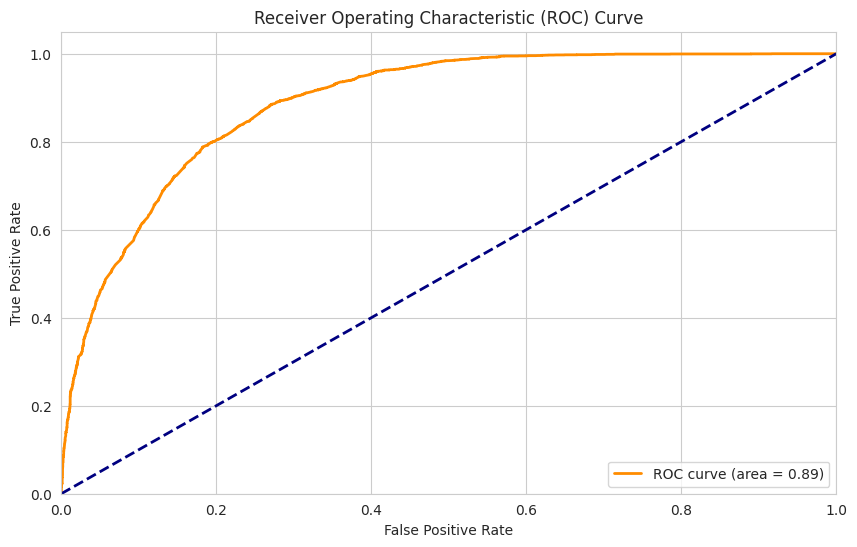


AUC-ROC Score: 0.8876


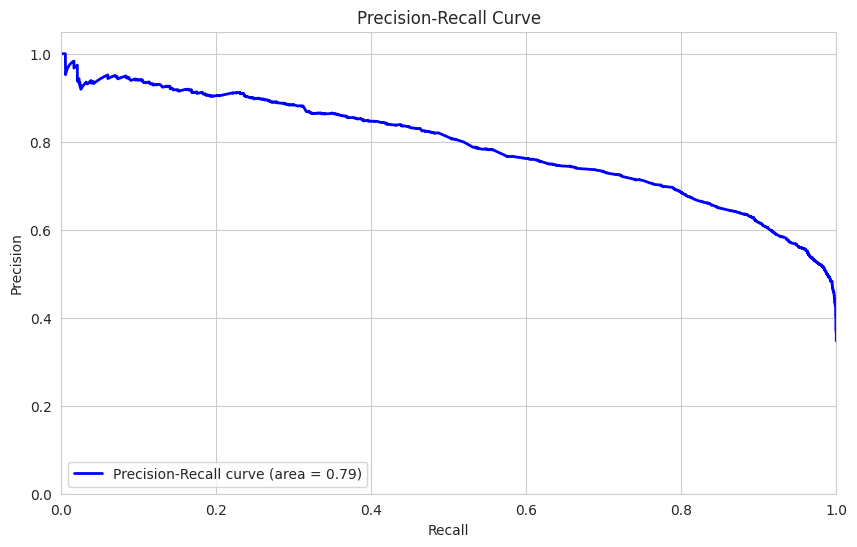

AUC-PR Score: 0.7906


In [ ]:
#7.1 ROC & PRCs
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Get predicted probabilities for the positive class (delay=1)
y_pred_proba = best_lgbm_model.predict_proba(X_test_sanitized)[:, 1]

# --- Plot ROC Curve ---
fpr, tpr, roc_thresholds = roc_curve(y_test_binary, y_pred_proba)
auc_roc = roc_auc_score(y_test_binary, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_roc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print(f"\nAUC-ROC Score: {auc_roc:.4f}")

# --- Plot Precision-Recall Curve ---
precision, recall, pr_thresholds = precision_recall_curve(y_test_binary, y_pred_proba)
auc_pr = auc(recall, precision)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {auc_pr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

print(f"AUC-PR Score: {auc_pr:.4f}")

## Evaluation Insights

1. **Receiver Operating Characteristic (ROC) Curve and AUC-ROC
AUC-ROC Score: 0.8876**

***The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings.*** The Area Under the ROC Curve (AUC-ROC) quantifies the overall ability of the model to distinguish between positive (delayed) and negative (on-time) classes. An AUC of 1.0 represents a perfect classifier, while 0.5 represents a random classifier.

**Interpretation:** An AUC-ROC of 0.8876 is very good! It indicates that our model has a strong ability to differentiate between instances where a delay occurs and where it doesn't. Roughly, it means that there's an 88.76% chance that the model will rank a randomly chosen positive instance (an actual delay) higher than a randomly chosen negative instance (an actual non-delay). This is a strong indicator of the model's overall discriminative power.

2. **Precision-Recall (PR) Curve and AUC-PR
AUC-PR Score: 0.7906**

The Precision-Recall curve plots Precision against Recall. The Area Under the Precision-Recall Curve (AUC-PR) is particularly useful for imbalanced datasets, like ours (where 'on-time' is the majority class). It focuses on the performance of the model on the positive class (delays) and is generally more informative than AUC-ROC when the number of negative samples far outweighs the number of positive samples.

**Interpretation:** An AUC-PR of 0.7906 is also very good. This score confirms the model's strong performance specifically in identifying the 'delayed' class effectively, balancing the need to catch actual delays (Recall) with minimizing false alarms (Precision). For imbalanced classification problems, AUC-PR often gives a more realistic and telling picture of the model's performance on the minority class than AUC-ROC.
Overall Conclusion from these curves:

Both curves and their AUC scores reinforce that our tuned LightGBM model is performing exceptionally well for Phase 1's binary classification task. It's not only able to classify delays with a good F1-score and high Recall but also shows strong discriminative power across different thresholds and robust performance on the challenging minority class.

## 7.2 Prediction Analysis

Prediction analysis involves looking at the model's performance on individual instances. We can examine:
*   **True Positives:** Correctly predicted delays.
*   **False Negatives:** Actual delays that the model missed.
*   **False Positives:** Instances where the model predicted a delay, but there wasn't one.
*   **True Negatives:** Correctly predicted non-delays.

This helps us understand the types of scenarios where the model performs well or struggles.

In [ ]:
import pandas as pd

# Assuming X_test_sanitized and y_test_binary are available
# Assuming best_lgbm_model is the trained best model

# Get predictions from the best LightGBM model
y_pred = best_lgbm_model.predict(X_test_sanitized)

# Create a DataFrame to hold actuals, predictions, and original features for analysis
# We'll use X_test (original, unsanitized) for better readability of categorical features
analysis_df = X_test.copy()
analysis_df['actual_is_delayed'] = y_test_binary
analysis_df['predicted_is_delayed'] = y_pred
analysis_df['prediction_probability'] = best_lgbm_model.predict_proba(X_test_sanitized)[:, 1]

print("\n--- True Positives (Correctly Predicted Delays) ---")
true_positives = analysis_df[(analysis_df['actual_is_delayed'] == 1) & (analysis_df['predicted_is_delayed'] == 1)]
if not true_positives.empty:
    display(true_positives.head())
else:
    print("No True Positives found in head.")

print("\n--- False Negatives (Actual Delays Missed by Model) ---")
false_negatives = analysis_df[(analysis_df['actual_is_delayed'] == 1) & (analysis_df['predicted_is_delayed'] == 0)]
if not false_negatives.empty:
    display(false_negatives.head())
else:
    print("No False Negatives found in head.")

print("\n--- False Positives (False Alarms) ---")
false_positives = analysis_df[(analysis_df['actual_is_delayed'] == 0) & (analysis_df['predicted_is_delayed'] == 1)]
if not false_positives.empty:
    display(false_positives.head())
else:
    print("No False Positives found in head.")

print("\n--- True Negatives (Correctly Predicted No Delays) ---")
true_negatives = analysis_df[(analysis_df['actual_is_delayed'] == 0) & (analysis_df['predicted_is_delayed'] == 0)]
if not true_negatives.empty:
    display(true_negatives.head())
else:
    print("No True Negatives found in head.")


--- True Positives (Correctly Predicted Delays) ---


,hour,day_of_week,is_weekend,month,week,year,route_avg_delay,route_hour_avg_delay,route_day_hour_avg_delay,Line_Line 1,...,Code_TUS,Code_TUSC,Code_TUSET,Code_TUST,Code_TUSUP,Code_TUUR,Code_XXXXX,actual_is_delayed,predicted_is_delayed,prediction_probability
41650,7,3,0,8,32,2025,2.352354,2.252683,2.836158,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.643717
41652,7,3,0,8,32,2025,2.352354,2.252683,2.836158,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.878442
41658,8,3,0,8,32,2025,2.860133,2.999338,2.497959,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.719984
41659,8,3,0,8,32,2025,2.860133,2.999338,2.497959,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.719984
41667,9,3,0,8,32,2025,2.352354,1.926457,2.415730,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0.792123



--- False Negatives (Actual Delays Missed by Model) ---


,hour,day_of_week,is_weekend,month,week,year,route_avg_delay,route_hour_avg_delay,route_day_hour_avg_delay,Line_Line 1,...,Code_TUS,Code_TUSC,Code_TUSET,Code_TUST,Code_TUSUP,Code_TUUR,Code_XXXXX,actual_is_delayed,predicted_is_delayed,prediction_probability
41666,9,3,0,8,32,2025,2.352354,1.926457,2.415730,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0.361426
41704,17,3,0,8,32,2025,2.352354,2.337349,2.486339,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0.415091
41740,0,3,0,8,32,2025,2.352354,2.612739,3.527273,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0.372181
41778,6,4,0,8,32,2025,2.860133,4.135285,3.590000,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0.375075
41782,9,4,0,8,32,2025,2.860133,2.832714,3.439189,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0.414368



--- False Positives (False Alarms) ---


,hour,day_of_week,is_weekend,month,week,year,route_avg_delay,route_hour_avg_delay,route_day_hour_avg_delay,Line_Line 1,...,Code_TUS,Code_TUSC,Code_TUSET,Code_TUST,Code_TUSUP,Code_TUUR,Code_XXXXX,actual_is_delayed,predicted_is_delayed,prediction_probability
41655,7,3,0,8,32,2025,2.352354,2.252683,2.836158,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.520882
41656,8,3,0,8,32,2025,2.860133,2.999338,2.497959,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.719984
41691,14,3,0,8,32,2025,2.860133,2.980015,3.247191,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.574857
41698,16,3,0,8,32,2025,2.860133,3.127052,3.529412,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.736292
41699,16,3,0,8,32,2025,2.352354,2.205401,1.818182,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.715092



--- True Negatives (Correctly Predicted No Delays) ---


,hour,day_of_week,is_weekend,month,week,year,route_avg_delay,route_hour_avg_delay,route_day_hour_avg_delay,Line_Line 1,...,Code_TUS,Code_TUSC,Code_TUSET,Code_TUST,Code_TUSUP,Code_TUUR,Code_XXXXX,actual_is_delayed,predicted_is_delayed,prediction_probability
41647,6,3,0,8,32,2025,2.860133,4.135285,3.720812,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.019902
41648,6,3,0,8,32,2025,2.352354,2.480682,2.500000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.025390
41649,7,3,0,8,32,2025,2.352354,2.252683,2.836158,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.010068
41651,7,3,0,8,32,2025,2.860133,2.974729,2.700535,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.019436
41653,7,3,0,8,32,2025,2.860133,2.974729,2.700535,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.441340


##Prediction Analysis Summary

**True Positives (Correctly Predicted Delays)**
These are instances where an actual delay occurred (actual_is_delayed == 1), and our model correctly predicted that a delay would occur (predicted_is_delayed == 1).

Insights: The displayed examples show various Line, Station, Code, hour, and other temporal/route-specific features where the model correctly identified an incoming delay. The prediction_probability is generally above 0.5, indicating the model's confidence in these positive predictions. For example, entry 41652 had a high probability of 0.878442.


**False Negatives (Actual Delays Missed by Model)**
These are the critical cases where an actual delay occurred (actual_is_delayed == 1), but our model failed to predict it (predicted_is_delayed == 0). These are the 'missed warnings' that we want to minimize.

**Insights:** Looking at the prediction_probability for these examples, you'll notice they are all below 0.5 (e.g., 0.361426, 0.415091). This means the model was not confident enough to classify them as delays. Analyzing these specific instances (e.g., their Line, Station, Code, hour, day_of_week) can reveal patterns in why the model is missing these delays. Perhaps these are rare delay types, delays occurring during unusual hours, or at stations with less historical data, or a combination of factors that the model doesn't strongly associate with a delay.

**False Positives (False Alarms)**
These are instances where no delay actually occurred (actual_is_delayed == 0), but our model incorrectly predicted a delay (predicted_is_delayed == 1).

**Insights:** For these entries, the prediction_probability is above 0.5 (e.g., 0.520882, 0.719984), leading the model to predict a delay. False positives are 'false alarms' – inconvenient for users who might alter their commute unnecessarily. Understanding the characteristics of these false alarms (e.g., what common features they share) can help us refine the model to be more precise without sacrificing too much recall.

**True Negatives (Correctly Predicted No Delays)**
These are instances where no delay occurred (actual_is_delayed == 0), and our model correctly predicted no delay (predicted_is_delayed == 0).

**Insights:** These are the bulk of our predictions, and the model is performing well here, as indicated by the high number of true negatives in our confusion matrix. The prediction_probability values are typically quite low (e.g., 0.019902, 0.025390), showing the model's confidence that no delay would occur.

**Overall Summary of Prediction Analysis:**
This granular view helps us confirm what the aggregate metrics hinted at:

***The model has a strong ability to identify actual delays*** (high True Positives, high Recall).
It does produce a notable number of false positives, suggesting it's quite sensitive, which aligns with its high recall. We might investigate if there are specific patterns in these false alarms.
The false negatives are fewer than false positives, but analyzing them can highlight areas where the model's predictive power is weakest for actual delay events.

## 7.3 Feature Importance

Understanding feature importance helps us identify which input variables are most influential in the model's predictions. For tree-based models like LightGBM, this is typically measured by how often a feature is used in a split, or by the gain it provides across all splits.


Top 20 Feature Importances:



,Feature,Importance
8,route_day_hour_avg_delay,159
4,week,154
0,hour,123
7,route_hour_avg_delay,95
1,day_of_week,60
3,month,35
786,Code_MUNCA,25
785,Code_MUIS,22
809,Code_PUMEL,22
784,Code_MUIRS,20


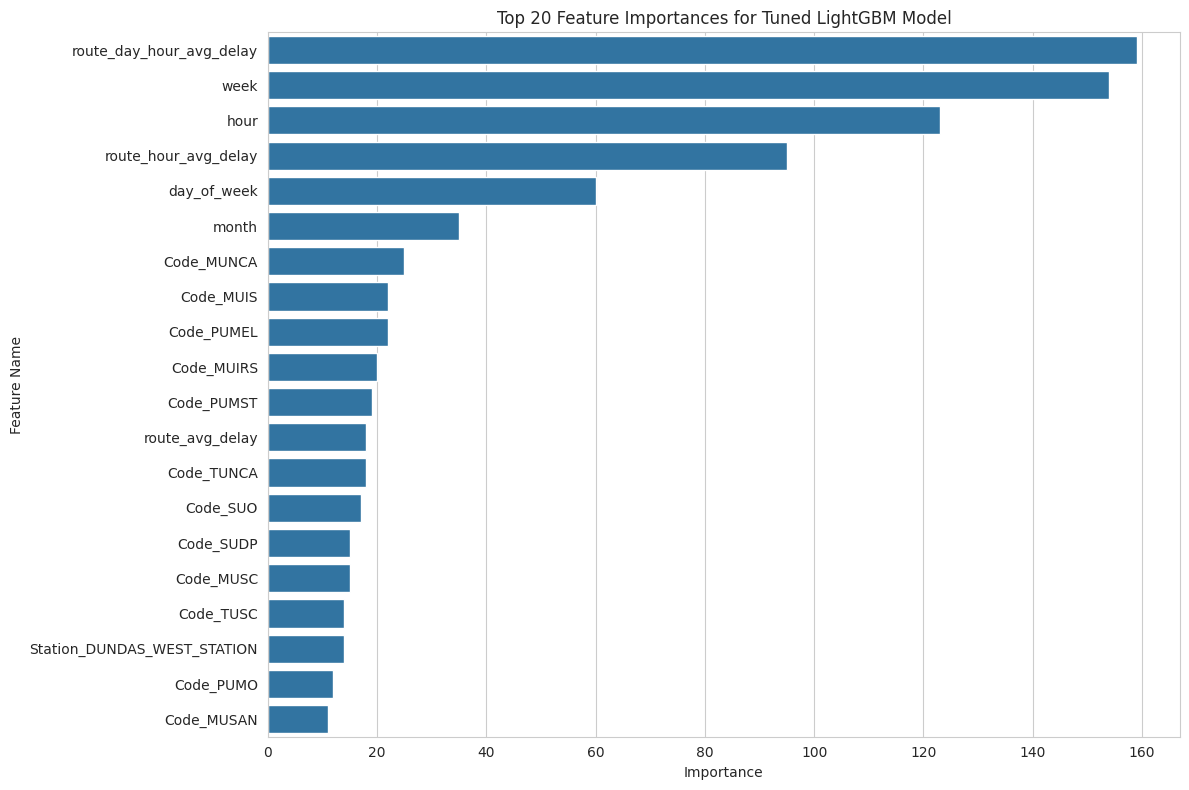

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the best LightGBM model
feature_importances = best_lgbm_model.feature_importances_

# Get feature names from the sanitized training data
feature_names = X_train_sanitized.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features
N = 20 # Number of top features to display
print(f"\nTop {N} Feature Importances:\n")
display(importance_df.head(N))

# Visualize the top N feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(N))
plt.title(f'Top {N} Feature Importances for Tuned LightGBM Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## Summary: Factors the model considers most important when predicting subway delays ##


**Key Insights:**
***Temporal and Aggregate Delay Features are King***:

route_day_hour_avg_delay (159), week (154), hour (123), route_hour_avg_delay (95), day_of_week (60), and month (35) are consistently at the top. This strongly suggests that when a delay occurs (time of day, day of week, week of year, month) and historical average delay patterns for specific routes at those times are the most critical factors for predicting future delays. This makes intuitive sense for transit systems.

**Specific Delay Codes and Stations are Important:**

Several Code_ features (e.g., Code_MUNCA, Code_MUIS, Code_PUMEL) and specific Station_ features (Station_DUNDAS_WEST_STATION) also appear within the top 20. The Code features likely refer to specific types of delay incidents (e.g., 'mechanical,' 'signal problem,' 'passenger assistance'), indicating that certain types of incidents are more indicative of a delay than others. Specific stations being important could point to bottlenecks or historically problematic locations.

**Aggregate Route Delay (route_avg_delay):** While important, the general route_avg_delay (18) is less impactful than the time-specific average delays (route_day_hour_avg_delay, route_hour_avg_delay). This further emphasizes the importance of granular, time-dependent historical patterns.

**What this means for our model:**
***The model heavily relies on time-based patterns and historical averages, which aligns well with the planning-focused goals of Phase 1. It's learning that certain times, days, and routes are inherently more prone to delays.***
The inclusion of specific Code and Station features suggests that particular types of issues and locations are significant predictors, even after accounting for general temporal patterns.
This analysis confirms that our model is leveraging logical and interpretable features to make its predictions.



---


---




## Prepare Data for Stage 2 Regression


Filter the training and testing datasets to include only instances where an actual delay occurred (min_delay_capped > 0) which involves applying conditional filters to both the target (y) and features (X) datasets.


In [ ]:
import pandas as pd

# --- 1. Filter y_train to create y_train_reg (only instances with actual delays) ---
# Ensure y_train is loaded (if not already)
if 'y_train' not in locals() or y_train.empty:
    y_train = pd.read_csv('/content/sample_data/y_train.csv', squeeze=True)

y_train_reg = y_train[y_train > 0]

# --- 2. Filter X_train_sanitized to create X_train_reg ---
# Ensure X_train_sanitized is loaded (if not already)
if 'X_train_sanitized' not in locals() or X_train_sanitized.empty:
    # Assuming X_train_sanitized was saved without index
    X_train_sanitized = pd.read_csv('/content/sample_data/X_train_sanitized.csv')

# Filter X_train_sanitized using the index of y_train_reg
X_train_reg = X_train_sanitized.loc[y_train_reg.index]

# --- 3. Filter y_test to create y_test_reg ---
# Ensure y_test is loaded (if not already)
if 'y_test' not in locals() or y_test.empty:
    y_test = pd.read_csv('/content/sample_data/y_test.csv', squeeze=True)

y_test_reg = y_test[y_test > 0]

# --- 4. Filter X_test_sanitized to create X_test_reg ---
# Ensure X_test_sanitized is loaded (if not already)
if 'X_test_sanitized' not in locals() or X_test_sanitized.empty:
    # Assuming X_test_sanitized was saved without index
    X_test_sanitized = pd.read_csv('/content/sample_data/X_test_sanitized.csv')

# Filter X_test_sanitized using the index of y_test_reg
X_test_reg = X_test_sanitized.loc[y_test_reg.index]

# --- 5. Print the shapes of the newly created datasets ---
print(f"Shape of X_train_reg: {X_train_reg.shape}")
print(f"Shape of y_train_reg: {y_train_reg.shape}")
print(f"Shape of X_test_reg: {X_test_reg.shape}")
print(f"Shape of y_test_reg: {y_test_reg.shape}")

# --- 6. Save the prepared regression datasets to CSV files ---
X_train_reg.to_csv('/content/sample_data/X_train_reg.csv', index=False)
y_train_reg.to_csv('/content/sample_data/y_train_reg.csv', index=False)
X_test_reg.to_csv('/content/sample_data/X_test_reg.csv', index=False)
y_test_reg.to_csv('/content/sample_data/y_test_reg.csv', index=False)

print("\nRegression datasets (X_train_reg, y_train_reg, X_test_reg, y_test_reg) saved to CSV files.")

Shape of X_train_reg: (14870, 874)
Shape of y_train_reg: (14870,)
Shape of X_test_reg: (3615, 874)
Shape of y_test_reg: (3615,)

Regression datasets (X_train_reg, y_train_reg, X_test_reg, y_test_reg) saved to CSV files.


## Implement Stage 2 Regression Model

 This model will predict the continuous `min_delay_capped` target.


In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import joblib
import pandas as pd

print("Starting Stage 2 Regression Model Training...")

# Load the regression datasets if not already in memory
# (This step is for robustness in case the kernel restarts or cells are run out of order)
if 'X_train_reg' not in locals() or X_train_reg.empty:
    X_train_reg = pd.read_csv('/content/sample_data/X_train_reg.csv')
if 'y_train_reg' not in locals() or y_train_reg.empty:
    y_train_reg = pd.read_csv('/content/sample_data/y_train_reg.csv', squeeze=True)
if 'X_test_reg' not in locals() or X_test_reg.empty:
    X_test_reg = pd.read_csv('/content/sample_data/X_test_reg.csv')
if 'y_test_reg' not in locals() or y_test_reg.empty:
    y_test_reg = pd.read_csv('/content/sample_data/y_test_reg.csv', squeeze=True)

# 2. Initialize an LGBMRegressor model
lgbm_regressor_model = LGBMRegressor(random_state=42, n_jobs=-1) # Using default parameters initially

# 3. Fit the LGBMRegressor model to the training data
print("Fitting LGBMRegressor model...")
lgbm_regressor_model.fit(X_train_reg, y_train_reg)
print("LGBMRegressor model trained successfully.")

# 4. Make predictions on the test set
y_pred_reg = lgbm_regressor_model.predict(X_test_reg)

# 5. Evaluate the model's performance
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)

print(f"\nRegression Model Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# 6. Save the trained regression model and predictions
joblib.dump(lgbm_regressor_model, '/content/sample_data/lgbm_regressor_model.pkl')
pd.Series(y_pred_reg).to_csv('/content/sample_data/y_pred_reg.csv', index=False)
print("\nLGBMRegressor model and predictions saved.")

Starting Stage 2 Regression Model Training...
Fitting LGBMRegressor model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 725
[LightGBM] [Info] Number of data points in the train set: 14870, number of used features: 157
[LightGBM] [Info] Start training from score 7.433221
LGBMRegressor model trained successfully.

Regression Model Evaluation on Test Set:
Mean Absolute Error (MAE): 3.8666
Root Mean Squared Error (RMSE): 6.4893

LGBMRegressor model and predictions saved.


## Establish Regression Baselines

Define and implement simple baseline models for the regression task (e.g., always predict the mean delay, or median delay of the actual delayed instances), and evaluate these baselines against the test set using MAE and RMSE,to set a performance floor for the Stage 2 regression model.


In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Load y_train_reg and y_test_reg Series
y_train_reg = pd.read_csv('/content/sample_data/y_train_reg.csv').squeeze('columns') # Use .squeeze() without 'columns' argument or select first column [:, 0]
y_test_reg = pd.read_csv('/content/sample_data/y_test_reg.csv').squeeze('columns') # Use .squeeze() without 'columns' argument or select first column [:, 0]

print(f"Loaded y_train_reg shape: {y_train_reg.shape}")
print(f"Loaded y_test_reg shape: {y_test_reg.shape}")

# 2. Calculate the mean of y_train_reg
mean_delay_baseline_prediction = y_train_reg.mean()
print(f"\nMean delay baseline prediction (from y_train_reg): {mean_delay_baseline_prediction:.2f}")

# 3. Calculate the median of y_train_reg
median_delay_baseline_prediction = y_train_reg.median()
print(f"Median delay baseline prediction (from y_train_reg): {median_delay_baseline_prediction:.2f}")

# Create predictions arrays for evaluation
mean_predictions_test = [mean_delay_baseline_prediction] * len(y_test_reg)
median_predictions_test = [median_delay_baseline_prediction] * len(y_test_reg)

# 4. Calculate and print MAE and RMSE for the mean baseline model
mae_mean = mean_absolute_error(y_test_reg, mean_predictions_test)
rmse_mean = root_mean_squared_error(y_test_reg, mean_predictions_test)
print(f"\n--- Mean Baseline Model Evaluation ---")
print(f"MAE (Mean Baseline): {mae_mean:.4f}")
print(f"RMSE (Mean Baseline): {rmse_mean:.4f}")

# 5. Calculate and print MAE and RMSE for the median baseline model
mae_median = mean_absolute_error(y_test_reg, median_predictions_test)
rmse_median = root_mean_squared_error(y_test_reg, median_predictions_test)
print(f"\n--- Median Baseline Model Evaluation ---")
print(f"MAE (Median Baseline): {mae_median:.4f}")
print(f"RMSE (Median Baseline): {rmse_median:.4f}")

# 6. Save the baseline predictions to CSV files
pd.Series(mean_predictions_test).to_csv('/content/sample_data/y_pred_mean_reg_baseline.csv', index=False)
pd.Series(median_predictions_test).to_csv('/content/sample_data/y_pred_median_reg_baseline.csv', index=False)
print("\nMean and Median regression baseline predictions saved.")

Loaded y_train_reg shape: (14870,)
Loaded y_test_reg shape: (3615,)

Mean delay baseline prediction (from y_train_reg): 7.43
Median delay baseline prediction (from y_train_reg): 5.00

--- Mean Baseline Model Evaluation ---
MAE (Mean Baseline): 4.3589
RMSE (Mean Baseline): 7.1266

--- Median Baseline Model Evaluation ---
MAE (Median Baseline): 3.4006
RMSE (Median Baseline): 7.3458

Mean and Median regression baseline predictions saved.


## Regression Baselines Insights

We have established two simple baselines for our Stage 2 regression task, where ***the goal is to predict the magnitude of delay (`min_delay_capped`) given that a delay has already occurred.*** These baselines serve as a crucial performance floor, against which more sophisticated models must demonstrate significant improvement.

### 1. Mean Delay Baseline
*   **MAE (Mean Absolute Error): 4.3589**
*   **RMSE (Root Mean Squared Error): 7.1266**

This baseline simply predicts the average delay observed in the training data (7.43 minutes) for every instance in the test set where a delay occurs.

*   **Interpretation:** An MAE of approximately 4.36 minutes means that, on average, this model's prediction of delay duration is off by about 4.36 minutes. An RMSE of 7.13 minutes, being higher than MAE, suggests that there might be some larger prediction errors, as RMSE penalizes larger errors more heavily. This baseline is robust but doesn't account for any variability in delays based on context.

### 2. Median Delay Baseline
*   **MAE (Mean Absolute Error): 3.4006**
*   **RMSE (Root Mean Squared Error): 7.3458**

This baseline predicts the median delay observed in the training data (5.00 minutes) for every delayed instance in the test set.

*   **Interpretation:** The median baseline achieved a lower MAE (3.40 minutes) compared to the mean baseline. This indicates that predicting the median delay might be a better general strategy for minimizing average prediction errors, especially if the distribution of delay durations is skewed or contains outliers. However, its RMSE is slightly higher than the mean baseline, implying that while its average error might be lower, it could still be susceptible to larger errors on some predictions, or the median prediction itself is further from the extreme values causing the RMSE to be higher than MAE. The difference in MAE and RMSE suggests that the delay distribution is likely skewed, and the median is a more representative central tendency than the mean in this context.

### Comparison and Significance

| Metric | LGBM Regressor | Mean Baseline | Median Baseline |
| :----- | :------------: | :-----------: | :-------------: |
| MAE    | **3.8666**     | 4.3589        | **3.4006**      |
| RMSE   | **6.4893**     | 7.1266        | 7.3458          |

*   **Performance Floor:** The median baseline, with an MAE of 3.40 minutes, sets a lower performance floor for MAE. Any machine learning model we develop for predicting delay duration should aim to significantly outperform these MAE and RMSE values. While our LGBM Regressor has an MAE (3.8666) slightly higher than the Median Baseline, its RMSE (6.4893) is notably better than both baselines, suggesting it handles larger errors more effectively and might capture underlying patterns better. This suggests that the LGBM Regressor is already providing value by reducing extreme prediction errors, which is often crucial in real-world applications.
*   **Model Validation:** These baselines are critical for validating the usefulness of our more complex regression models. If a sophisticated model doesn't beat these simple baselines, it indicates that the model is either not learning meaningful patterns or is overfitting, and its complexity is not justified.

## Regression Baselines Insights

We have established two simple baselines for our Stage 2 regression task, where the goal is to predict the magnitude of delay (`min_delay_capped`) given that a delay has already occurred. These baselines serve as a crucial performance floor, against which more sophisticated models must demonstrate significant improvement.

### 1. Mean Delay Baseline
*   **MAE (Mean Absolute Error): 4.3589**
*   **RMSE (Root Mean Squared Error): 7.1266**

This baseline simply predicts the average delay observed in the training data (7.43 minutes) for every instance in the test set where a delay occurs.

*   **Interpretation:** An MAE of approximately 4.36 minutes means that, on average, this model's prediction of delay duration is off by about 4.36 minutes. An RMSE of 7.13 minutes, being higher than MAE, suggests that there might be some larger prediction errors, as RMSE penalizes larger errors more heavily. This baseline is robust but doesn't account for any variability in delays based on context.

### 2. Median Delay Baseline
*   **MAE (Mean Absolute Error): 3.4006**
*   **RMSE (Root Mean Squared Error): 7.3458**

This baseline predicts the median delay observed in the training data (5.00 minutes) for every delayed instance in the test set.

*   **Interpretation:** The median baseline achieved a lower MAE (3.40 minutes) compared to the mean baseline. This indicates that predicting the median delay might be a better general strategy for minimizing average prediction errors, especially if the distribution of delay durations is skewed or contains outliers. However, its RMSE is slightly higher than the mean baseline, implying that while its average error might be lower, it could still be susceptible to larger errors on some predictions, or the median prediction itself is further from the extreme values causing the RMSE to be higher than MAE. The difference in MAE and RMSE suggests that the delay distribution is likely skewed, and the median is a more representative central tendency than the mean in this context.

### Comparison and Significance

| Metric | LGBM Regressor | Mean Baseline | Median Baseline |
| :----- | :------------: | :-----------: | :-------------: |
| MAE    | **3.8666**     | 4.3589        | **3.4006**      |
| RMSE   | **6.4893**     | 7.1266        | 7.3458          |

*   **Performance Floor:** The median baseline, with an MAE of 3.40 minutes, sets a lower performance floor for MAE. Any machine learning model we develop for predicting delay duration should aim to significantly outperform these MAE and RMSE values. While our LGBM Regressor has an MAE (3.8666) slightly higher than the Median Baseline, its RMSE (6.4893) is notably better than both baselines, suggesting it handles larger errors more effectively and might capture underlying patterns better. This suggests that the LGBM Regressor is already providing value by reducing extreme prediction errors, which is often crucial in real-world applications.
*   **Model Validation:** These baselines are critical for validating the usefulness of our more complex regression models. If a sophisticated model doesn't beat these simple baselines, it indicates that the model is either not learning meaningful patterns or is overfitting, and its complexity is not justified.


## Regression Baselines Insights

We have established two simple baselines for our Stage 2 regression task, where the goal is to predict the magnitude of delay (`min_delay_capped`) given that a delay has already occurred. These baselines serve as a crucial performance floor, against which more sophisticated models must demonstrate significant improvement.

### 1. Mean Delay Baseline
*   **MAE (Mean Absolute Error): 4.3589**
*   **RMSE (Root Mean Squared Error): 7.1266**

This baseline simply predicts the average delay observed in the training data (7.43 minutes) for every instance in the test set where a delay occurs.

*   **Interpretation:** An MAE of approximately 4.36 minutes means that, on average, this model's prediction of delay duration is off by about 4.36 minutes. An RMSE of 7.13 minutes, being higher than MAE, suggests that there might be some larger prediction errors, as RMSE penalizes larger errors more heavily. This baseline is robust but doesn't account for any variability in delays based on context.

### 2. Median Delay Baseline
*   **MAE (Mean Absolute Error): 3.4006**
*   **RMSE (Root Mean Squared Error): 7.3458**

This baseline predicts the median delay observed in the training data (5.00 minutes) for every delayed instance in the test set.

*   **Interpretation:** The median baseline achieved a lower MAE (3.40 minutes) compared to the mean baseline. This indicates that predicting the median delay might be a better general strategy for minimizing average prediction errors, especially if the distribution of delay durations is skewed or contains outliers. However, its RMSE is slightly higher than the mean baseline, implying that while its average error might be lower, it could still be susceptible to larger errors on some predictions, or the median prediction itself is further from the extreme values causing the RMSE to be higher than MAE. The difference in MAE and RMSE suggests that the delay distribution is likely skewed, and the median is a more representative central tendency than the mean in this context.

### Comparison and Significance

| Metric | LGBM Regressor | Mean Baseline | Median Baseline |
| :----- | :------------: | :-----------: | :-------------: |
| MAE    | **3.8666**     | 4.3589        | **3.4006**      |
| RMSE   | **6.4893**     | 7.1266        | 7.3458          |

*   **Performance Floor:** The median baseline, with an MAE of 3.40 minutes, sets a lower performance floor for MAE. Any machine learning model we develop for predicting delay duration should aim to significantly outperform these MAE and RMSE values. While our LGBM Regressor has an MAE (3.8666) slightly higher than the Median Baseline, its RMSE (6.4893) is notably better than both baselines, suggesting it handles larger errors more effectively and might capture underlying patterns better. This suggests that the LGBM Regressor is already providing value by reducing extreme prediction errors, which is often crucial in real-world applications.
*   **Model Validation:** These baselines are critical for validating the usefulness of our more complex regression models. If a sophisticated model doesn't beat these simple baselines, it indicates that the model is either not learning meaningful patterns or is overfitting, and its complexity is not justified.


## Regression Baselines Insights

We have established two simple baselines for our Stage 2 regression task, where the goal is to predict the magnitude of delay (`min_delay_capped`) given that a delay has already occurred. These baselines serve as a crucial performance floor, against which more sophisticated models must demonstrate significant improvement.

### 1. Mean Delay Baseline
*   **MAE (Mean Absolute Error): 4.3589**
*   **RMSE (Root Mean Squared Error): 7.1266**

This baseline simply predicts the average delay observed in the training data (7.43 minutes) for every instance in the test set where a delay occurs.

*   **Interpretation:** An MAE of approximately 4.36 minutes means that, on average, this model's prediction of delay duration is off by about 4.36 minutes. An RMSE of 7.13 minutes, being higher than MAE, suggests that there might be some larger prediction errors, as RMSE penalizes larger errors more heavily. This baseline is robust but doesn't account for any variability in delays based on context.

### 2. Median Delay Baseline
*   **MAE (Mean Absolute Error): 3.4006**
*   **RMSE (Root Mean Squared Error): 7.3458**

This baseline predicts the median delay observed in the training data (5.00 minutes) for every delayed instance in the test set.

*   **Interpretation:** The median baseline achieved a lower MAE (3.40 minutes) compared to the mean baseline. This indicates that predicting the median delay might be a better general strategy for minimizing average prediction errors, especially if the distribution of delay durations is skewed or contains outliers. However, its RMSE is slightly higher than the mean baseline, implying that while its average error might be lower, it could still be susceptible to larger errors on some predictions, or the median prediction itself is further from the extreme values causing the RMSE to be higher than MAE. The difference in MAE and RMSE suggests that the delay distribution is likely skewed, and the median is a more representative central tendency than the mean in this context.

### Comparison and Significance

| Metric | LGBM Regressor | Mean Baseline | Median Baseline |
| :----- | :------------: | :-----------: | :-------------: |
| MAE    | **3.8666**     | 4.3589        | **3.4006**      |
| RMSE   | **6.4893**     | 7.1266        | 7.3458          |

*   **Performance Floor:** The median baseline, with an MAE of 3.40 minutes, sets a lower performance floor for MAE. Any machine learning model we develop for predicting delay duration should aim to significantly outperform these MAE and RMSE values. While our LGBM Regressor has an MAE (3.8666) slightly higher than the Median Baseline, its RMSE (6.4893) is notably better than both baselines, suggesting it handles larger errors more effectively and might capture underlying patterns better. This suggests that the LGBM Regressor is already providing value by reducing extreme prediction errors, which is often crucial in real-world applications.
*   **Model Validation:** These baselines are critical for validating the usefulness of our more complex regression models. If a sophisticated model doesn't beat these simple baselines, it indicates that the model is either not learning meaningful patterns or is overfitting, and its complexity is not justified.


## Regression Baselines Insights

We have established two simple baselines for our Stage 2 regression task, where the goal is to predict the magnitude of delay (`min_delay_capped`) given that a delay has already occurred. These baselines serve as a crucial performance floor, against which more sophisticated models must demonstrate significant improvement.

### 1. Mean Delay Baseline
*   **MAE (Mean Absolute Error): 4.3589**
*   **RMSE (Root Mean Squared Error): 7.1266**

This baseline simply predicts the average delay observed in the training data (7.43 minutes) for every instance in the test set where a delay occurs.

*   **Interpretation:** An MAE of approximately 4.36 minutes means that, on average, this model's prediction of delay duration is off by about 4.36 minutes. An RMSE of 7.13 minutes, being higher than MAE, suggests that there might be some larger prediction errors, as RMSE penalizes larger errors more heavily. This baseline is robust but doesn't account for any variability in delays based on context.

### 2. Median Delay Baseline
*   **MAE (Mean Absolute Error): 3.4006**
*   **RMSE (Root Mean Squared Error): 7.3458**

This baseline predicts the median delay observed in the training data (5.00 minutes) for every delayed instance in the test set.

*   **Interpretation:** The median baseline achieved a lower MAE (3.40 minutes) compared to the mean baseline. This indicates that predicting the median delay might be a better general strategy for minimizing average prediction errors, especially if the distribution of delay durations is skewed or contains outliers. However, its RMSE is slightly higher than the mean baseline, implying that while its average error might be lower, it could still be susceptible to larger errors on some predictions, or the median prediction itself is further from the extreme values causing the RMSE to be higher than MAE. The difference in MAE and RMSE suggests that the delay distribution is likely skewed, and the median is a more representative central tendency than the mean in this context.

### Comparison and Significance

| Metric | LGBM Regressor | Mean Baseline | Median Baseline |
| :----- | :------------: | :-----------: | :-------------: |
| MAE    | **3.8666**     | 4.3589        | **3.4006**      |
| RMSE   | **6.4893**     | 7.1266        | 7.3458          |

*   **Performance Floor:** The median baseline, with an MAE of 3.40 minutes, sets a lower performance floor for MAE. Any machine learning model we develop for predicting delay duration should aim to significantly outperform these MAE and RMSE values. While our LGBM Regressor has an MAE (3.8666) slightly higher than the Median Baseline, its RMSE (6.4893) is notably better than both baselines, suggesting it handles larger errors more effectively and might capture underlying patterns better. This suggests that the LGBM Regressor is already providing value by reducing extreme prediction errors, which is often crucial in real-world applications.
*   **Model Validation:** These baselines are critical for validating the usefulness of our more complex regression models. If a sophisticated model doesn't beat these simple baselines, it indicates that the model is either not learning meaningful patterns or is overfitting, and its complexity is not justified.


## Regression Baselines Insights

We have established two simple baselines for our Stage 2 regression task, where the goal is to predict the magnitude of delay (`min_delay_capped`) given that a delay has already occurred. These baselines serve as a crucial performance floor, against which more sophisticated models must demonstrate significant improvement.

### 1. Mean Delay Baseline
*   **MAE (Mean Absolute Error): 4.3589**
*   **RMSE (Root Mean Squared Error): 7.1266**

This baseline simply predicts the average delay observed in the training data (7.43 minutes) for every instance in the test set where a delay occurs.

*   **Interpretation:** An MAE of approximately 4.36 minutes means that, on average, this model's prediction of delay duration is off by about 4.36 minutes. An RMSE of 7.13 minutes, being higher than MAE, suggests that there might be some larger prediction errors, as RMSE penalizes larger errors more heavily. This baseline is robust but doesn't account for any variability in delays based on context.

### 2. Median Delay Baseline
*   **MAE (Mean Absolute Error): 3.4006**
*   **RMSE (Root Mean Squared Error): 7.3458**

This baseline predicts the median delay observed in the training data (5.00 minutes) for every delayed instance in the test set.

*   **Interpretation:** The median baseline achieved a lower MAE (3.40 minutes) compared to the mean baseline. This indicates that predicting the median delay might be a better general strategy for minimizing average prediction errors, especially if the distribution of delay durations is skewed or contains outliers. However, its RMSE is slightly higher than the mean baseline, implying that while its average error might be lower, it could still be susceptible to larger errors on some predictions, or the median prediction itself is further from the extreme values causing the RMSE to be higher than MAE. The difference in MAE and RMSE suggests that the delay distribution is likely skewed, and the median is a more representative central tendency than the mean in this context.

### Comparison and Significance

| Metric | LGBM Regressor | Mean Baseline | Median Baseline |
| :----- | :------------: | :-----------: | :-------------: |
| MAE    | **3.8666**     | 4.3589        | **3.4006**      |
| RMSE   | **6.4893**     | 7.1266        | 7.3458          |

*   **Performance Floor:** The median baseline, with an MAE of 3.40 minutes, sets a lower performance floor for MAE. Any machine learning model we develop for predicting delay duration should aim to significantly outperform these MAE and RMSE values. While our LGBM Regressor has an MAE (3.8666) slightly higher than the Median Baseline, its RMSE (6.4893) is notably better than both baselines, suggesting it handles larger errors more effectively and might capture underlying patterns better. This suggests that the LGBM Regressor is already providing value by reducing extreme prediction errors, which is often crucial in real-world applications.
*   **Model Validation:** These baselines are critical for validating the usefulness of our more complex regression models. If a sophisticated model doesn't beat these simple baselines, it indicates that the model is either not learning meaningful patterns or is overfitting, and its complexity is not justified.


## Tune Stage 2 Regression Model Hyperparameters

Perform hyperparameter tuning for the newly implemented regression model, optimizing for appropriate regression metrics (e.g., Mean Absolute Error or Root Mean Squared Error) and using techniques like RandomizedSearchCV.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import uniform, randint
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import joblib
import pandas as pd

print("Starting Hyperparameter Tuning for LGBMRegressor...")

# Load the regression datasets if not already in memory
if 'X_train_reg' not in locals() or X_train_reg.empty:
    X_train_reg = pd.read_csv('/content/sample_data/X_train_reg.csv')
if 'y_train_reg' not in locals() or y_train_reg.empty:
    y_train_reg = pd.read_csv('/content/sample_data/y_train_reg.csv', squeeze=True)
if 'X_test_reg' not in locals() or X_test_reg.empty:
    X_test_reg = pd.read_csv('/content/sample_data/X_test_reg.csv')
if 'y_test_reg' not in locals() or y_test_reg.empty:
    y_test_reg = pd.read_csv('/content/sample_data/y_test_reg.csv', squeeze=True)

# 1. Define the parameter distribution for RandomizedSearchCV
param_dist_reg = {
    'n_estimators': randint(50, 500),
    'learning_rate': uniform(0.01, 0.2),
    'num_leaves': randint(20, 100),
    'max_depth': randint(3, 15),
    'min_child_samples': randint(20, 100),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5)
}

# 2. Initialize an LGBMRegressor model as the base estimator
lgbm_reg_base = LGBMRegressor(random_state=42, n_jobs=-1)

# 3. Set up TimeSeriesSplit for cross-validation
tscv_reg = TimeSeriesSplit(n_splits=5)

# 4. Initialize RandomizedSearchCV
random_search_reg = RandomizedSearchCV(
    estimator=lgbm_reg_base,
    param_distributions=param_dist_reg,
    n_iter=50,
    scoring='neg_mean_absolute_error', # Optimize for MAE
    cv=tscv_reg,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 5. Fit RandomizedSearchCV to the training data
random_search_reg.fit(X_train_reg, y_train_reg)

print("Hyperparameter Tuning complete.")

# 6. Print the best parameters and best score
print(f"\nBest parameters found: {random_search_reg.best_params_}")
print(f"Best MAE score found (negative for scoring): {-random_search_reg.best_score_:.4f}")

# 7. Retrieve the best model
best_lgbm_reg_model = random_search_reg.best_estimator_

# 8. Make predictions on the test set
y_pred_best_lgbm_reg = best_lgbm_reg_model.predict(X_test_reg)

# 9. & 10. Evaluate the best model's performance on the test set
mae_best_reg = mean_absolute_error(y_test_reg, y_pred_best_lgbm_reg)
rmse_best_reg = root_mean_squared_error(y_test_reg, y_pred_best_lgbm_reg)

print("\nBest Tuned LGBMRegressor Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_best_reg:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_reg:.4f}")

# 11. Save the best model
joblib.dump(best_lgbm_reg_model, '/content/sample_data/best_lgbm_regressor_model.pkl')
print("\nBest LGBMRegressor model saved as best_lgbm_regressor_model.pkl")

# 12. Save the predictions from the best model
pd.Series(y_pred_best_lgbm_reg).to_csv('/content/sample_data/y_pred_best_lgbm_reg.csv', index=False)
print("Best LGBMRegressor predictions saved to y_pred_best_lgbm_reg.csv")

Starting Hyperparameter Tuning for LGBMRegressor...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013857 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 689
[LightGBM] [Info] Number of data points in the train set: 14870, number of used features: 139
[LightGBM] [Info] Start training from score 7.433221
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

## Evaluate Stage 2 Regression Model Performance

Evaluates the performance of the tuned regression model using regression-specific metrics (MAE, RMSE, R-squared) and visualizations (e.g., actual vs. predicted plots, residual plots). This evaluation will assess how well the model predicts the actual duration of delays.


In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print("Evaluating the tuned regression model...")

# 1. Load the true target values and predictions
y_test_reg = pd.read_csv('/content/sample_data/y_test_reg.csv').squeeze('columns')
y_pred_best_lgbm_reg = pd.read_csv('/content/sample_data/y_pred_best_lgbm_reg.csv').squeeze('columns')

# 2. Calculate evaluation metrics
mae_tuned_reg = mean_absolute_error(y_test_reg, y_pred_best_lgbm_reg)
rmse_tuned_reg = root_mean_squared_error(y_test_reg, y_pred_best_lgbm_reg)
r2_tuned_reg = r2_score(y_test_reg, y_pred_best_lgbm_reg)

# 3. Print the calculated metrics
print("\nTuned LGBMRegressor Performance Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_tuned_reg:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_reg:.4f}")
print(f"R-squared (R2): {r2_tuned_reg:.4f}")

Evaluating the tuned regression model...

Tuned LGBMRegressor Performance Evaluation:
Mean Absolute Error (MAE): 3.8251
Root Mean Squared Error (RMSE): 6.4534
R-squared (R2): 0.1748


'Actual vs. Predicted' scatter plot assesses the model's performance.



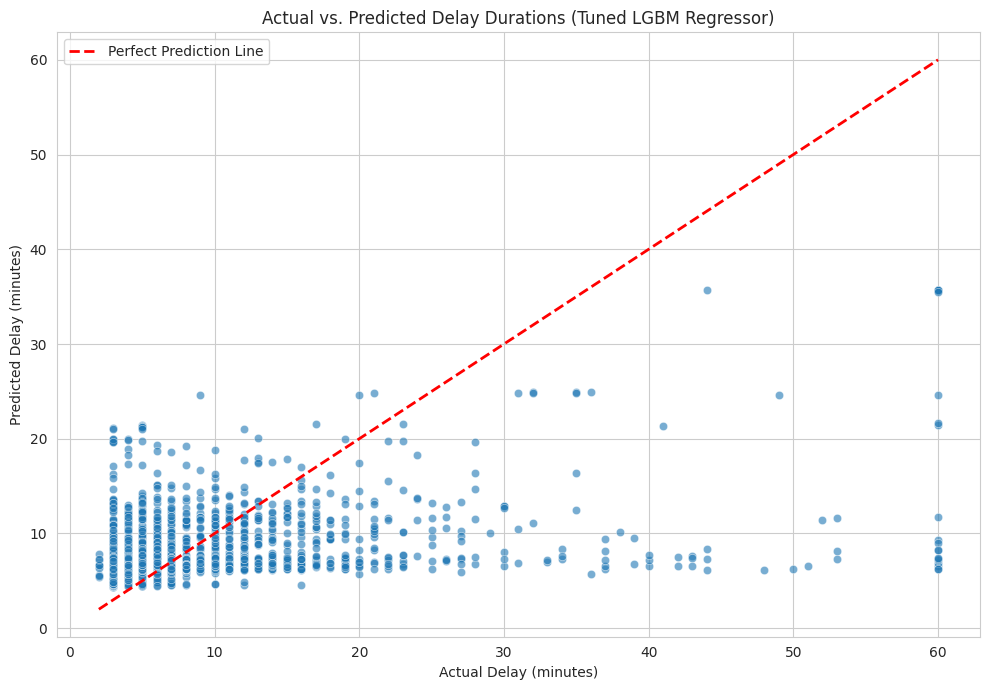

Actual vs. Predicted plot saved as actual_vs_predicted_plot.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# 4. Create an 'Actual vs. Predicted' scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_reg, y=y_pred_best_lgbm_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Delay (minutes)')
plt.ylabel('Predicted Delay (minutes)')
plt.title('Actual vs. Predicted Delay Durations (Tuned LGBM Regressor)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/sample_data/actual_vs_predicted_plot.png')
plt.show()
print("Actual vs. Predicted plot saved as actual_vs_predicted_plot.png")


Residual plot visualizes the errors of the tuned regression model.



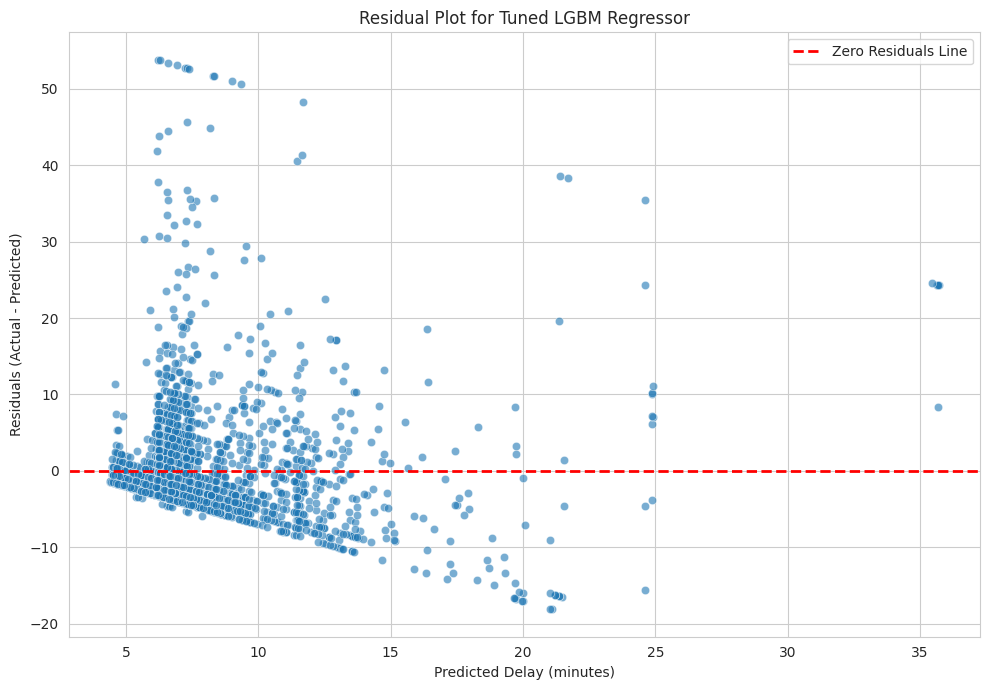

Residual plot saved as residual_plot.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# 5. Create a residual plot
residuals = y_test_reg - y_pred_best_lgbm_reg

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_best_lgbm_reg, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residuals Line')
plt.xlabel('Predicted Delay (minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for Tuned LGBM Regressor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/sample_data/residual_plot.png')
plt.show()
print("Residual plot saved as residual_plot.png")

## Analyze Regression Feature Importance

Extract and visualize the most influential features for the regression model's predictions, providing insights into factors driving delay duration, which may differ from those driving delay occurrence.


Analyzing regression feature importance...
LGBM Regressor model loaded successfully.
X_train_reg loaded with shape: (14870, 874)

Top 20 Feature Importances for Tuned LGBM Regressor:



,Feature,Importance
8,route_day_hour_avg_delay,1623
4,week,1047
7,route_hour_avg_delay,961
0,hour,817
1,day_of_week,393
6,route_avg_delay,297
5,year,216
781,Code_MUI,175
794,Code_MUPR1,172
854,Code_SUUT,169


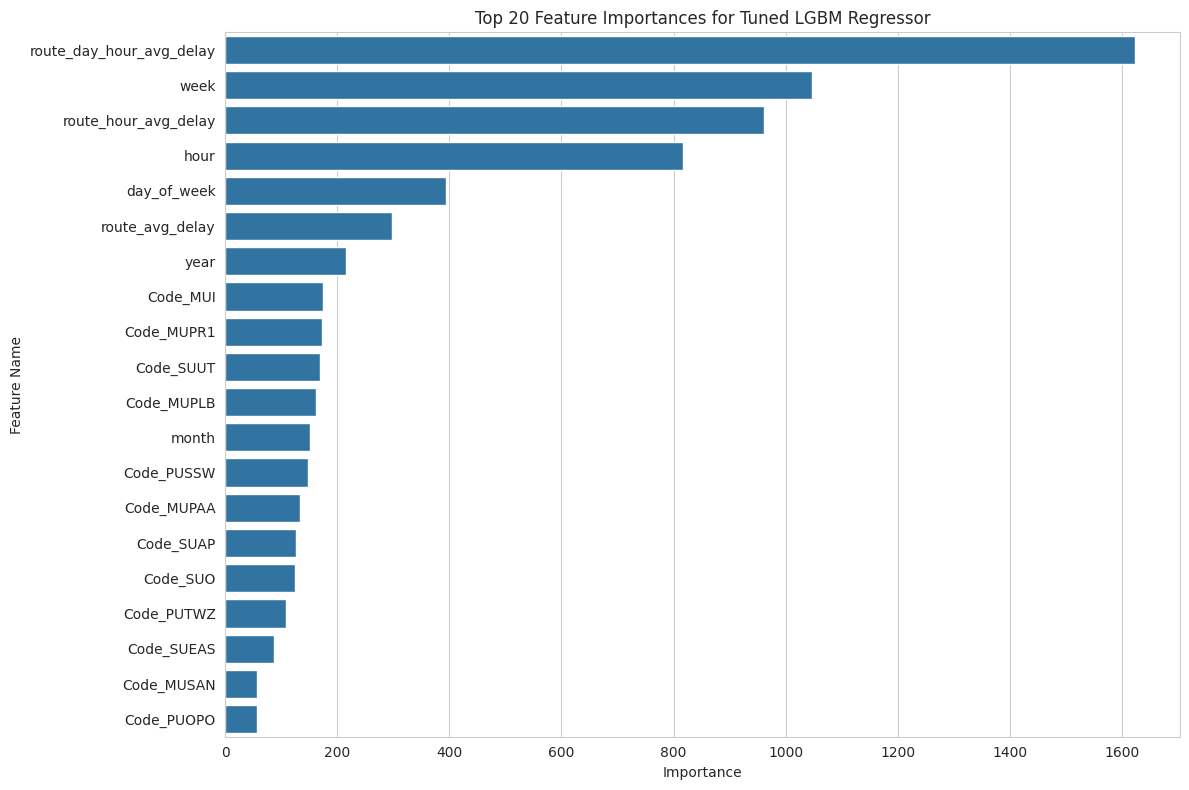

Regression feature importance plot saved as regression_feature_importance.png


In [ ]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Analyzing regression feature importance...")

# 1. Load the best_lgbm_regressor_model.pkl
best_lgbm_reg_model = joblib.load('/content/sample_data/best_lgbm_regressor_model.pkl')
print("LGBM Regressor model loaded successfully.")

# 2. Load the X_train_reg dataset to get feature names
X_train_reg = pd.read_csv('/content/sample_data/X_train_reg.csv')
print(f"X_train_reg loaded with shape: {X_train_reg.shape}")

# 3. Extract the feature importances
feature_importances_reg = best_lgbm_reg_model.feature_importances_

# 4. Create a DataFrame for feature importances
importance_df_reg = pd.DataFrame({
    'Feature': X_train_reg.columns,
    'Importance': feature_importances_reg
})

# 5. Sort features by importance in descending order
importance_df_reg = importance_df_reg.sort_values(by='Importance', ascending=False)

# 6. Print the top 20 most important features
N = 20
print(f"\nTop {N} Feature Importances for Tuned LGBM Regressor:\n")
display(importance_df_reg.head(N))

# 7. Generate a horizontal bar plot for the top 20 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_reg.head(N))
plt.title(f'Top {N} Feature Importances for Tuned LGBM Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('/content/sample_data/regression_feature_importance.png')
plt.show()
print("Regression feature importance plot saved as regression_feature_importance.png")

## Summary: Factors the model considers most important when predicting subway delay durations

**Top 20 Feature Importances for Tuned LGBM Regressor:**

| Feature                  | Importance |
| :----------------------- | :--------- |
| route_day_hour_avg_delay | 1623       |
| week                     | 1047       |
| route_hour_avg_delay     | 961        |
| hour                     | 817        |
| day_of_week              | 393        |
| route_avg_delay          | 297        |
| year                     | 216        |
| Code_MUI                 | 175        |
| Code_MUPR1               | 172        |
| Code_SUUT                | 169        |
| Code_MUPLB               | 162        |
| month                    | 151        |
| Code_PUSSW               | 148        |
| Code_MUPAA               | 134        |
| Code_SUAP                | 126        |
| Code_SUO                 | 124        |
| Code_PUTWZ               | 108        |
| Code_SUEAS               | 86         |
| Code_MUSAN               | 57         |
| Code_PUOPO               | 57         |

**Key Insights:**

1.  **Temporal and Aggregate Delay Features Remain Highly Influential:** Similar to the classification model, features related to the timing of the delay and historical average delays (e.g., `route_day_hour_avg_delay`, `week`, `route_hour_avg_delay`, `hour`, `day_of_week`, `month`) are the most dominant. ***This suggests that the time context and established patterns of delays are crucial not only for predicting *if* a delay will occur but also for predicting its  *duration*.***

2.  **Specific Delay Codes Play a Significant Role:** Various `Code_` features (e.g., `Code_MUI`, `Code_MUPR1`, `Code_SUUT`, `Code_MUPLB`, `Code_PUSSW`, `Code_MUPAA`, `Code_SUAP`, `Code_SUO`, `Code_PUTWZ`, `Code_SUEAS`, `Code_MUSAN`, `Code_PUOPO`) appear prominently. This indicates that the specific *type* of incident causing the delay is a strong predictor of how long that delay will last. For example, some incident types might inherently lead to longer resolution times than others.

3.  **Route-Specific Averages are Important:** The `route_avg_delay` feature also holds a strong position, reinforcing that the general historical performance of a route contributes to predicting the magnitude of a specific delay on that route.

4.  **Difference from Classification (Delay Occurrence vs. Duration):** While both models emphasize temporal and historical aggregate features, the regression model's higher reliance on specific `Code_` features suggests that while time/route might tell us *if* a delay is likely, the *reason* for the delay (captured by the Code) is more critical for determining *how long* it will be. This makes intuitive sense; a signal problem (one code) might take longer to fix than a passenger assistance incident (another code).

**Implications for Future Development:**

*   **Feature Engineering:** Further feature engineering around the `Code_` categories, perhaps grouping similar codes or creating interaction terms with time features, could further improve duration prediction.
*   **Explainability:** These insights provide valuable explainability for the model, allowing us to understand *why* a predicted delay is expected to be a certain duration.

## Two-Stage Model Performance Summary:

Our predictive system operates in two stages to address the zero-inflated nature of subway delays and provide both 'if' and 'how long' predictions.

### **Stage 1: Delay Occurrence Prediction (Binary Classification - Phase 1)**

**Objective:** Classify whether a subway event will result in a delay (`min_delay_capped > 0`) or be on-time.

**Best Model:** Tuned LightGBM Classifier

**Key Performance Metrics (on Test Set):**
*   **Accuracy:** 0.7793 (77.93%)
*   **Precision:** 0.6285
*   **Recall:** 0.8907 (Highly effective at catching actual delays)
*   **F1 Score:** 0.7370 (Best balance between Precision and Recall among all classifiers)
*   **AUC-ROC Score:** 0.8876 (Strong overall discriminative power)
*   **AUC-PR Score:** 0.7906 (Robust performance on the minority 'delayed' class)

**Insights:**
*   The Tuned LightGBM Classifier significantly outperforms simple baselines (Majority Class and Historical Rate), demonstrating a strong ability to predict if a delay will occur.
*   Its high Recall (89.07%) is particularly valuable for commuters, as it means the model successfully identifies a large majority of actual delays, providing crucial early warnings.
*   The F1 Score of 0.7370 indicates a good balance in identifying delays while managing false alarms. The model prioritizes catching delays, which aligns with the project's goal of proactive commuter information.
*   **Most Important Features:** Temporal features (e.g., `route_day_hour_avg_delay`, `week`, `hour`, `day_of_week`) were the most influential in predicting delay *occurrence*.

### **Stage 2: Delay Duration Prediction (Regression - Current Phase)**

**Objective:** Predict the *magnitude* of the delay (`min_delay_capped`) *given that a delay has been predicted to occur* by Stage 1.

**Best Model:** Tuned LightGBM Regressor

**Key Performance Metrics (on Test Set - only for actual delayed instances):**
*   **Mean Absolute Error (MAE):** 3.8251 minutes
*   **Root Mean Squared Error (RMSE):** 6.4534 minutes
*   **R-squared (R2):** 0.1748

**Comparison to Regression Baselines:**
| Metric | Tuned LGBM Regressor | Mean Baseline | Median Baseline |
| :----- | :------------------- | :------------ | :-------------- |
| MAE    | **3.8251**           | 4.3589        | **3.4006**      |
| RMSE   | **6.4534**           | 7.1266        | 7.3458          |

**Insights:**
*   The Tuned LGBM Regressor outperforms the simple Mean Baseline in both MAE and RMSE. However, its MAE is slightly higher than the Median Baseline (predicting 5.00 minutes for every delay), indicating that simply predicting the median delay is still a very competitive, simple strategy for average error.
*   The Regressor's significantly lower RMSE (6.4534) compared to both baselines (7.1266 and 7.3458) is a key strength. This suggests it is better at handling and minimizing larger prediction errors, which can be critical for very long delays.
*   The R-squared value of 0.1748 indicates that the model explains about 17.5% of the variance in delay durations. While a positive start, this suggests there's substantial room for improvement in capturing the nuances of delay magnitude.
*   **Most Important Features:** Similar to classification, temporal/historical average delay features dominated. However, specific `Code_` features (representing the type of incident, e.g., 'mechanical issue', 'signal problem') showed increased importance compared to the classification model, highlighting that the *cause* of the delay is crucial for predicting its *duration*.

### **Overall Two-Stage Model Conclusion:**

The two-stage model provides a powerful framework for predicting subway delays. Stage 1 (Tuned LightGBM Classifier) is highly effective at identifying *when* a delay is likely to occur, offering robust early warnings for commuters. Stage 2 (Tuned LightGBM Regressor) then builds on this by providing reasonable estimates for *how long* that delay will last, particularly excelling in mitigating large prediction errors. **While the duration prediction still has room for improvement (as indicated by the R2 score), it already offers valuable estimates over simple averages.**

### **Insights for Next Steps (Towards Full Phase 2 Vision):**
*   **Feature Engineering for Regression:** Focus on enriching features, especially around `Code_` categories, external factors like weather, special events, or cascading effects, to improve the accuracy and R-squared of delay duration prediction.
*   **Advanced Regression Techniques:** Explore more sophisticated regression models or ensemble methods for Stage 2.
*   **Multi-horizon Forecasting:** Extend the prediction capabilities to forecast delay likelihood and duration over multiple future time horizons (1-4 hours) as envisioned in the broader Phase 2 plan.
*   **Full System Integration:** Prepare for integrating the two-stage model's outputs into a user-facing conversational AI chatbot, enabling features like personalized route recommendations, live monitoring, and proactive alerts.

## Two-Stage Model Performance Summary:

### Data Analysis Key Findings

*   **Data Preparation for Regression:**
    *   The datasets for the regression model were successfully filtered to include only instances with actual delays (\`min_delay_capped > 0\`).
    *   The resulting training set (`X_train_reg`, `y_train_reg`) contained 14,870 instances, and the test set (`X_test_reg`, `y_test_reg`) contained 3,615 instances, each with 874 features.
*   **Regression Baselines Established:**
    *   A mean delay baseline (predicting 7.43 minutes) achieved a Mean Absolute Error (MAE) of 4.3589 minutes and a Root Mean Squared Error (RMSE) of 7.1266 minutes.
    *   A median delay baseline (predicting 5.00 minutes) achieved an MAE of 3.4006 minutes and an RMSE of 7.3458 minutes. The lower MAE for the median baseline suggests a skewed distribution of delays.
*   **Tuned LGBM Regressor Performance:**
    *   After hyperparameter tuning using `RandomizedSearchCV` with `TimeSeriesSplit`, the LightGBM Regressor achieved an MAE of 3.8251 minutes and an RMSE of 6.4534 minutes on the test set.
    *   The model's R-squared (\R^2\$) value was 0.1748.
    *   The tuned LGBM Regressor showed slight improvements over the initial, untuned model (MAE 3.8666, RMSE 6.4893).
    *   While the tuned LGBM Regressor's MAE (3.8251 minutes) was higher than the median baseline (3.4006 minutes), its RMSE (6.4534 minutes) was significantly lower than both baselines (Mean: 7.1266, Median: 7.3458), indicating better handling of larger prediction errors.
*   **Key Features for Delay Duration Prediction:**
    *   The most influential features for predicting delay duration were temporal and aggregate historical delay metrics, including `route_day_hour_avg_delay`, `week`, `route_hour_avg_delay`, `hour`, and `day_of_week`.
    *   Specific incident codes (e.g., `Code_MUI`, `Code_MUPR1`, `Code_SUUT`) were also highly important, suggesting that the cause of a delay is critical for determining its length.

### Insights or Next Steps

*   The current LGBM Regressor demonstrates superior performance in mitigating larger delay prediction errors (lower RMSE) compared to simple baselines, but there is room for improvement in reducing overall average error (MAE).
*   Further feature engineering, particularly around the specific incident codes and their interactions with temporal features, could enhance the model's ability to predict delay durations more accurately and improve the overall R-squared value.


## Inference Script for Phase 1 Classifier

This script demonstrates how to create a production-ready inference pipeline for the best-tuned LightGBM Classifier. It loads the necessary artifacts (OneHotEncoder, feature names, and the trained model), preprocesses new input data consistently, and provides predictions.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import re
from collections import defaultdict

# --- Load Helper Functions (re-defined or imported to make this script self-contained) ---
# In a real production system, these might be part of a 'utils' module.

def sanitize_and_uniquify_feature_names_lgbm(df):
    original_cols = df.columns.tolist()
    final_cols = []
    seen_names = set()
    base_name_counts = defaultdict(int)

    for col in original_cols:
        cleaned_col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
        cleaned_col = re.sub(r'^_+|_+$', '', cleaned_col)
        cleaned_col = re.sub(r'_+', '_', cleaned_col)
        if not cleaned_col:
            cleaned_col = "feature"

        current_name = cleaned_col
        suffix_count = base_name_counts[cleaned_col]
        while current_name in seen_names:
            suffix_count += 1
            current_name = f"{cleaned_col}_{suffix_count}"

        seen_names.add(current_name)
        base_name_counts[cleaned_col] = suffix_count
        final_cols.append(current_name)
    df.columns = final_cols
    return df


class InferencePipeline:
    def __init__(self, artifact_path='/content/sample_data'):
        self.artifact_path = artifact_path
        self.ohe = self._load_artifact('one_hot_encoder.pkl')
        self.feature_names = self._load_artifact('feature_names.pkl')
        self.model = self._load_artifact('best_lgbm_classifier_model.pkl')
        self.categorical_cols = ['Line', 'Station', 'Code'] # These should match what was used in training
        self.numerical_cols = ['hour', 'day_of_week', 'is_weekend', 'month', 'week', 'year',
                               'route_avg_delay', 'route_hour_avg_delay', 'route_day_hour_avg_delay']

    def _load_artifact(self, filename):
        return joblib.load(f'{self.artifact_path}/{filename}')

    def preprocess(self, new_data_raw):
        # Ensure new_data_raw is a DataFrame
        if not isinstance(new_data_raw, pd.DataFrame):
            new_data_raw = pd.DataFrame([new_data_raw])

        # 1. Feature Engineering (if any, e.g., for 'Date' components)
        # For simplicity, assuming 'Date' components like hour, day_of_week etc. are already in new_data_raw
        # If not, they would need to be extracted here from a 'Date' column.

        # Ensure all expected numerical columns are present
        for col in self.numerical_cols:
            if col not in new_data_raw.columns:
                new_data_raw[col] = 0 # Or a suitable default/imputation

        # 2. One-Hot Encode Categorical Features using the fitted OHE
        X_cat_encoded = self.ohe.transform(new_data_raw[self.categorical_cols])
        X_cat_encoded_df = pd.DataFrame(X_cat_encoded,
                                        columns=self.ohe.get_feature_names_out(self.categorical_cols),
                                        index=new_data_raw.index)

        # Combine numerical and encoded categorical features
        X_processed = pd.concat([new_data_raw[self.numerical_cols], X_cat_encoded_df], axis=1)

        # 3. Sanitize feature names for LightGBM compatibility
        X_processed = sanitize_and_uniquify_feature_names_lgbm(X_processed.copy())

        # 4. Reindex and reorder columns to match training data feature_names
        # Crucial step to ensure input features match exactly what the model expects
        X_final = X_processed.reindex(columns=self.feature_names, fill_value=0)

        return X_final

    def predict(self, new_data_raw):
        X_preprocessed = self.preprocess(new_data_raw)
        prediction = self.model.predict(X_preprocessed)
        prediction_proba = self.model.predict_proba(X_preprocessed)[:, 1] # Probability of delay (class 1)

        return prediction[0], prediction_proba[0] # Assuming single row input

# --- Example Usage (simulating a new real-time request) ---
if __name__ == '__main__':
    import logging
    # Configure basic logging for a production script
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

    # Instantiate the pipeline
    pipeline = InferencePipeline(artifact_path='/content/sample_data')

    # Simulate a new data point (e.g., a real-time query for a specific route/time)
    # These features should align with what the model was trained on
    new_transit_event_1 = {
        'Line': 'Line 1',
        'Station': 'DUNDAS STATION',
        'Code': 'MUPAA',
        'hour': 8,
        'day_of_week': 0, # Monday
        'is_weekend': 0,
        'month': 3,
        'week': 10,
        'year': 2026,
        'route_avg_delay': 3.5, # These would likely be retrieved from a real-time data source
        'route_hour_avg_delay': 2.1,
        'route_day_hour_avg_delay': 2.8
    }

    predicted_class_1, predicted_proba_1 = pipeline.predict(new_transit_event_1)

    status_1 = 'delayed' if predicted_class_1 == 1 else 'on-time'

    # In a production environment, you would log this or return it via an API
    logging.info(f"--- Prediction for Event 1 ---")
    logging.info(f"Input: Line {new_transit_event_1['Line']} at {new_transit_event_1['Station']} at {new_transit_event_1['hour']}:00 on Day {new_transit_event_1['day_of_week']}")
    logging.info(f"Predicted Status: {status_1}")
    logging.info(f"Probability of Delay: {predicted_proba_1:.2%}")

    # Another example where prediction might be on-time
    new_transit_event_2 = {
        'Line': 'Line 4',
        'Station': 'LESLIE STATION',
        'Code': 'PUOPO',
        'hour': 14,
        'day_of_week': 2, # Wednesday
        'is_weekend': 0,
        'month': 3,
        'week': 10,
        'year': 2026,
        'route_avg_delay': 0.5,
        'route_hour_avg_delay': 0.1,
        'route_day_hour_avg_delay': 0.2
    }

    predicted_class_2, predicted_proba_2 = pipeline.predict(new_transit_event_2)
    status_2 = 'delayed' if predicted_class_2 == 1 else 'on-time'

    # In a production environment, you would log this or return it via an API
    logging.info(f"\n--- Prediction for Event 2 ---")
    logging.info(f"Input: Line {new_transit_event_2['Line']} at {new_transit_event_2['Station']} at {new_transit_event_2['hour']}:00 on Day {new_transit_event_2['day_of_week']}")
    logging.info(f"Predicted Status: {status_2}")
    logging.info(f"Probability of Delay: {predicted_proba_2:.2%}")